# Experiment 4: Head-to-Head
**Head-to-Head:** 5-fold CV comparing DecisionTree, AdaBoost, RandomForest, and sklearn RF.


In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
# === Imports and Setup ===
import os
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier as SkRF
from sklearn.model_selection import StratifiedKFold

sys.path.insert(0, os.path.abspath(".."))

from src.metrics.evaluation import (
    accuracy_calculation,
    f1_score,
    auc_roc,
)
from src.trees.bagging.random_forest import RandomForestClassifier
from src.trees.boosting.adaboost import AdaBoostClassifier
from src.trees.decision_tree import DecisionTree
from src.utils.preprocessing import (
    load_adult_income_data,
    load_breast_cancer,
    load_covertype_data,
    load_mnist_data,
)
matplotlib.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
## 1. Load Dataset

Using Breast Cancer Wisconsin , Adult Income, Covertype, Mnist dataset 

In [3]:
data = load_breast_cancer()
X, y = data.data, data.target
print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Classes: {np.unique(y)} ({len(np.unique(y))} classes)")
print(f"Class distribution: {np.bincount(y)}")

X_adult, y_adult, df_adult = load_adult_income_data()
Z = X_adult
t = t = y_adult.str.strip().map({
    '<=50K': 0,
    '>50K': 1
}).values
print(f"Samples: {Z.shape[0]}, Features: {Z.shape[1]}")
print(f"Classes: {np.unique(t)} ({len(np.unique(t))} classes)")
print(f"Class distribution: {np.bincount(t)}")

A, b, df_cover = load_covertype_data()
b = b.values
print(f"Samples: {A.shape[0]}, Features: {A.shape[1]}")
print(f"Classes: {np.unique(b)} ({len(np.unique(b))} classes)")
print(f"Class distribution: {np.bincount(b)}")

M, n, df_mnist = load_mnist_data()
n = n.values 
print(f"Samples: {M.shape[0]}, Features: {M.shape[1]}")
print(f"Classes: {np.unique(n)} ({len(np.unique(n))} classes)")
print(f"Class distribution: {np.bincount(n)}")

Samples: 569, Features: 30
Classes: [0 1] (2 classes)
Class distribution: [212 357]
Loaded from Parquet: /Users/student/Desktop/ML_PROJECT-main/data/adult_income.parquet
Samples: 48842, Features: 6
Classes: [0 1] (2 classes)
Class distribution: [37155 11687]
Loaded from Parquet: /Users/student/Desktop/ML_PROJECT-main/data/covertype.parquet
Samples: 581012, Features: 10
Classes: [1 2 3 4 5 6 7] (7 classes)
Class distribution: [     0 211840 283301  35754   2747   9493  17367  20510]
Loaded from Parquet: /Users/student/Desktop/ML_PROJECT-main/data/mnist.parquet
Samples: 70000, Features: 784
Classes: [0 1 2 3 4 5 6 7 8 9] (10 classes)
Class distribution: [6903 7877 6990 7141 6824 6313 6876 7293 6825 6958]


---
## Experiment 4: Head-to-Head (5-fold CV)

Compare DecisionTree, AdaBoost (100 estimators), RandomForest (100 trees), and sklearn RF.
5-fold stratified CV. Report accuracy, macro F1, AUC-ROC as mean +/- std.
Box plots for visual comparison.

In [4]:
# ============================================================
# Breast Cancer
# ============================================================
X_bc = np.asarray(
    X,
    dtype=np.float32,
)

y_bc = np.asarray(
    y,
    dtype=np.int64,
).ravel()


# ============================================================
# Adult Income
# ============================================================
# Bəzi dataset versiyalarında label-lar:
# ">50K", ">50K.", "<=50K", "<=50K." ola bilər.

if hasattr(y_adult, "columns"):
    adult_labels = y_adult.iloc[:, 0]
else:
    adult_labels = y_adult

adult_labels = (
    adult_labels
    .astype(str)
    .str.strip()
    .str.rstrip(".")
)

adult_target = adult_labels.map({
    "<=50K": 0,
    ">50K": 1,
})

adult_valid_mask = adult_target.notna().to_numpy()

X_adult_clean = np.asarray(
    Z,
    dtype=np.float32,
)[adult_valid_mask]

y_adult_clean = adult_target[
    adult_valid_mask
].to_numpy(
    dtype=np.int64
)

# ============================================================
# Covertype
# ============================================================
X_cover = np.asarray(
    A,
    dtype=np.float32,
)

y_cover = np.asarray(
    b,
    dtype=np.int64,
).ravel()

# Class-lar 1-7 gəlirsə, 0-6 formatına çeviririk
y_cover = y_cover - y_cover.min()
# İlk 1000 sample götürürük
X_cover = X_cover[:1000]
y_cover = y_cover[:1000]

# ============================================================
# MNIST
# ============================================================
X_mnist = np.asarray(
    M,
    dtype=np.float32,
)[:1000]

y_mnist = np.asarray(
    n,
    dtype=np.int64,
).ravel()[:1000]


# ============================================================
# Dataset dictionary
# ============================================================
datasets = {
    "Breast Cancer": (
        X_bc,
        y_bc,
    ),
    "Adult Income": (
        X_adult_clean,
        y_adult_clean,
    ),
    "Covertype": (
        X_cover,
        y_cover,
    ),
    "MNIST": (
        X_mnist,
        y_mnist,
    ),
}

MODEL_NAMES = (
    "Single Tree",
    "AdaBoost",
    "Random Forest",
    "sklearn RF",
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

all_fold_results = []

for dataset_name, (X_data, y_data) in datasets.items():
    classes, counts = np.unique(
        y_data,
        return_counts=True,
    )

    if counts.min() < 5:
        raise ValueError(
            f"{dataset_name}: every class must contain "
            "at least 5 samples for 5-fold CV."
        )

    print(f"\n{dataset_name}")
    print(f"X shape: {X_data.shape}")
    print(f"y shape: {y_data.shape}")
    print(
        "Classes:",
        dict(
            zip(
                classes.tolist(),
                counts.tolist(),
            )
        ),
    )


Breast Cancer
X shape: (569, 30)
y shape: (569,)
Classes: {0: 212, 1: 357}

Adult Income
X shape: (48842, 6)
y shape: (48842,)
Classes: {0: 37155, 1: 11687}

Covertype
X shape: (1000, 10)
y shape: (1000,)
Classes: {0: 226, 1: 585, 4: 189}

MNIST
X shape: (1000, 784)
y shape: (1000,)
Classes: {0: 97, 1: 116, 2: 99, 3: 93, 4: 105, 5: 92, 6: 94, 7: 117, 8: 87, 9: 100}


In [5]:
def calculate_metrics(
    model,
    X_test,
    y_test,
):
    y_test = np.asarray(
        y_test
    ).ravel()

    predictions = np.asarray(
        model.predict(X_test)
    ).ravel()

    probabilities = np.asarray(
        model.predict_proba(X_test),
        dtype=np.float64,
    )

    if probabilities.ndim != 2:
        raise ValueError(
            "predict_proba() must return a 2D array."
        )

    if probabilities.shape[0] != y_test.shape[0]:
        raise ValueError(
            "Probability rows must match test samples."
        )

    accuracy = accuracy_calculation(
        y_test,
        predictions,
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        mean="macro",
    )

    auc = auc_roc(
        y_test,
        probabilities,
    )

    return {
        "accuracy": float(accuracy),
        "macro_f1": float(macro_f1),
        "auc_roc": float(auc),
    }

In [6]:
def run_model_on_fold(
    dataset_name,
    fold,
    train_idx,
    test_idx,
    X_data,
    y_data,
    model_name,
):
    X_train = X_data[train_idx]
    X_test = X_data[test_idx]

    y_train = y_data[train_idx]
    y_test = y_data[test_idx]

    model_seed = (
        RANDOM_STATE + fold
    )

    if model_name == "Single Tree":
        model = DecisionTree(
            random_state=model_seed,
        )

    elif model_name == "AdaBoost":
        model = AdaBoostClassifier(
            n_estimators=100,
            random_state=model_seed,
        )

    elif model_name == "Random Forest":
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=model_seed,

            # Xaricdə Parallel istifadə etdiyimiz üçün
            # burada əlavə proses açmırıq.
            n_jobs=1,
        )

    elif model_name == "sklearn RF":
        model = SkRF(
            n_estimators=100,
            random_state=model_seed,
            n_jobs=1,
        )

    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

    model.fit(
        X_train,
        y_train,
    )

    metrics = calculate_metrics(
        model,
        X_test,
        y_test,
    )

    return {
        "dataset": dataset_name,
        "fold": fold,
        "model": model_name,
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "auc_roc": metrics["auc_roc"],
    }

In [7]:
cpu_count = os.cpu_count() or 2

# Pure Python custom modellər üçün process-based parallelism.
# Maksimum 6 proses RAM-ın həddindən artıq dolmasının qarşısını alır.
N_JOBS = max(
    1,
    min(
        cpu_count - 1,
        6,
    ),
)

print(f"Detected CPUs: {cpu_count}")
print(f"Parallel workers: {N_JOBS}")

all_fold_results = []

for dataset_name, (
    X_data,
    y_data,
) in datasets.items():

    print(f"\n{'=' * 70}")
    print(f"Processing: {dataset_name}")
    print(f"{'=' * 70}")

    # Contiguous float32 array həm RAM, həm də paylaşma üçün daha uyğundur
    X_data = np.ascontiguousarray(
        X_data,
        dtype=np.float32,
    )

    y_data = np.ascontiguousarray(
        y_data,
        dtype=np.int64,
    )

    folds = list(
        skf.split(
            X_data,
            y_data,
        )
    )

    tasks = [
        (
            fold,
            train_idx,
            test_idx,
            model_name,
        )
        for fold, (
            train_idx,
            test_idx,
        ) in enumerate(
            folds,
            start=1,
        )
        for model_name in MODEL_NAMES
    ]

    dataset_results = Parallel(
        n_jobs=N_JOBS,

        # Pure Python custom tree-lər üçün threading yox,
        # process-based loky daha məqsədəuyğundur.
        backend="loky",

        # Böyük X array-ləri worker-lərə kopyalamaq əvəzinə
        # read-only memory map ilə paylaşılır.
        max_nbytes="20M",
        mmap_mode="r",

        # Hər worker bir model/fold task götürür.
        batch_size=1,

        # Həddindən artıq task RAM-a əvvəlcədən yüklənmir.
        pre_dispatch=N_JOBS,

        verbose=10,
    )(
        delayed(run_model_on_fold)(
            dataset_name=dataset_name,
            fold=fold,
            train_idx=train_idx,
            test_idx=test_idx,
            X_data=X_data,
            y_data=y_data,
            model_name=model_name,
        )
        for (
            fold,
            train_idx,
            test_idx,
            model_name,
        ) in tasks
    )

    all_fold_results.extend(
        dataset_results
    )

    print(
        f"Completed: {dataset_name}"
    )

Detected CPUs: 10
Parallel workers: 6

Processing: Breast Cancer


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 tasks      | elapsed:    1.2s
[Parallel(n_jobs=6)]: Done   7 tasks      | elapsed:    3.7s
[Parallel(n_jobs=6)]: Done  12 tasks      | elapsed:    4.5s
[Parallel(n_jobs=6)]: Done  18 out of  20 | elapsed:    8.5s remaining:    0.9s
[Parallel(n_jobs=6)]: Done  20 out of  20 | elapsed:    9.2s finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Completed: Breast Cancer

Processing: Adult Income


[Parallel(n_jobs=6)]: Done   2 tasks      | elapsed:    5.0s
[Parallel(n_jobs=6)]: Done   7 tasks      | elapsed:   24.5s
[Parallel(n_jobs=6)]: Done  12 tasks      | elapsed:   41.0s
[Parallel(n_jobs=6)]: Done  18 out of  20 | elapsed:  2.4min remaining:   15.8s
[Parallel(n_jobs=6)]: Done  20 out of  20 | elapsed:  2.8min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 tasks      | elapsed:    0.2s


Completed: Adult Income

Processing: Covertype


[Parallel(n_jobs=6)]: Done   7 tasks      | elapsed:    1.6s
[Parallel(n_jobs=6)]: Done  12 tasks      | elapsed:    2.1s
[Parallel(n_jobs=6)]: Done  18 out of  20 | elapsed:    5.1s remaining:    0.6s
[Parallel(n_jobs=6)]: Done  20 out of  20 | elapsed:    7.0s finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Completed: Covertype

Processing: MNIST


[Parallel(n_jobs=6)]: Done   2 tasks      | elapsed:    4.2s
[Parallel(n_jobs=6)]: Done   7 tasks      | elapsed:   15.9s
[Parallel(n_jobs=6)]: Done  12 tasks      | elapsed:   30.0s
[Parallel(n_jobs=6)]: Done  18 out of  20 | elapsed:   52.7s remaining:    5.9s


Completed: MNIST


[Parallel(n_jobs=6)]: Done  20 out of  20 | elapsed:  1.2min finished


In [8]:
fold_results_df = pd.DataFrame(
    all_fold_results
)

model_order = {
    model_name: index
    for index, model_name in enumerate(
        MODEL_NAMES
    )
}

fold_results_df["model_order"] = (
    fold_results_df["model"]
    .map(model_order)
)

fold_results_df = (
    fold_results_df
    .sort_values(
        by=[
            "dataset",
            "model_order",
            "fold",
        ]
    )
    .drop(
        columns="model_order"
    )
    .reset_index(
        drop=True
    )
)

print(
    f"Total completed experiments: "
    f"{len(fold_results_df)}"
)

display(
    fold_results_df
)

Total completed experiments: 80


,dataset,fold,model,accuracy,macro_f1,auc_roc
0,Adult Income,1,Single Tree,0.770908,0.689372,0.691813
1,Adult Income,2,Single Tree,0.778892,0.700369,0.703565
2,Adult Income,3,Single Tree,0.768735,0.687290,0.690537
3,Adult Income,4,Single Tree,0.775696,0.694623,0.696437
4,Adult Income,5,Single Tree,0.774161,0.688515,0.688797
...,...,...,...,...,...,...
75,MNIST,1,sklearn RF,0.915000,0.915383,0.992735
76,MNIST,2,sklearn RF,0.835000,0.830834,0.985639
77,MNIST,3,sklearn RF,0.890000,0.884685,0.986093
78,MNIST,4,sklearn RF,0.880000,0.878595,0.988967


In [11]:
METRIC_COLUMNS = (
    "accuracy",
    "macro_f1",
    "auc_roc",
)

summary_rows = []

for (
    dataset_name,
    model_name,
), group in fold_results_df.groupby(
    [
        "dataset",
        "model",
    ],
    sort=False,
):
    row = {
        "Dataset": dataset_name,
        "Model": model_name,
    }

    for metric_name in METRIC_COLUMNS:
        values = group[
            metric_name
        ].to_numpy(
            dtype=float
        )

        metric_mean = np.mean(
            values
        )

        metric_std = np.std(
            values,
            ddof=1,
        )

        row[metric_name] = (
            f"{metric_mean:.4f} ± "
            f"{metric_std:.4f}"
        )

    summary_rows.append(row)

summary_table = pd.DataFrame(
    summary_rows
)

summary_table["model_order"] = (
    summary_table["Model"]
    .map(model_order)
)

summary_table = (
    summary_table
    .sort_values(
        by=[
            "Dataset",
            "model_order",
        ]
    )
    .drop(
        columns="model_order"
    )
    .rename(
        columns={
            "accuracy": "Accuracy",
            "macro_f1": "Macro F1",
            "auc_roc": "AUC-ROC",
        }
    )
    .reset_index(
        drop=True
    )
)

display(
    summary_table
)

,Dataset,Model,Accuracy,Macro F1,AUC-ROC
0,Adult Income,Single Tree,0.7737 ± 0.0040,0.6920 ± 0.0054,0.6942 ± 0.0059
1,Adult Income,AdaBoost,0.8317 ± 0.0056,0.7228 ± 0.0090,0.8535 ± 0.0083
2,Adult Income,Random Forest,0.8379 ± 0.0040,0.7378 ± 0.0078,0.8587 ± 0.0065
3,Adult Income,sklearn RF,0.8083 ± 0.0028,0.7205 ± 0.0044,0.8245 ± 0.0053
4,Breast Cancer,Single Tree,0.9104 ± 0.0208,0.9041 ± 0.0227,0.9048 ± 0.0257
5,Breast Cancer,AdaBoost,0.9666 ± 0.0200,0.9639 ± 0.0217,0.9935 ± 0.0070
6,Breast Cancer,Random Forest,0.9543 ± 0.0114,0.9509 ± 0.0125,0.9913 ± 0.0080
7,Breast Cancer,sklearn RF,0.9526 ± 0.0228,0.9489 ± 0.0255,0.9878 ± 0.0096
8,Covertype,Single Tree,0.7420 ± 0.0148,0.7252 ± 0.0137,0.7942 ± 0.0163
9,Covertype,AdaBoost,0.6830 ± 0.0402,0.6317 ± 0.0414,0.8287 ± 0.0381


In [12]:
for dataset_name in summary_table[
    "Dataset"
].unique():

    print(f"\n{'=' * 70}")
    print(dataset_name)
    print(f"{'=' * 70}")

    dataset_table = (
        summary_table[
            summary_table["Dataset"]
            == dataset_name
        ]
        .drop(
            columns="Dataset"
        )
        .reset_index(
            drop=True
        )
    )

    display(
        dataset_table
    )


Adult Income


,Model,Accuracy,Macro F1,AUC-ROC
0,Single Tree,0.7737 ± 0.0040,0.6920 ± 0.0054,0.6942 ± 0.0059
1,AdaBoost,0.8317 ± 0.0056,0.7228 ± 0.0090,0.8535 ± 0.0083
2,Random Forest,0.8379 ± 0.0040,0.7378 ± 0.0078,0.8587 ± 0.0065
3,sklearn RF,0.8083 ± 0.0028,0.7205 ± 0.0044,0.8245 ± 0.0053



Breast Cancer


,Model,Accuracy,Macro F1,AUC-ROC
0,Single Tree,0.9104 ± 0.0208,0.9041 ± 0.0227,0.9048 ± 0.0257
1,AdaBoost,0.9666 ± 0.0200,0.9639 ± 0.0217,0.9935 ± 0.0070
2,Random Forest,0.9543 ± 0.0114,0.9509 ± 0.0125,0.9913 ± 0.0080
3,sklearn RF,0.9526 ± 0.0228,0.9489 ± 0.0255,0.9878 ± 0.0096



Covertype


,Model,Accuracy,Macro F1,AUC-ROC
0,Single Tree,0.7420 ± 0.0148,0.7252 ± 0.0137,0.7942 ± 0.0163
1,AdaBoost,0.6830 ± 0.0402,0.6317 ± 0.0414,0.8287 ± 0.0381
2,Random Forest,0.8180 ± 0.0329,0.7855 ± 0.0418,0.9211 ± 0.0261
3,sklearn RF,0.8190 ± 0.0303,0.7884 ± 0.0357,0.9269 ± 0.0264



MNIST


,Model,Accuracy,Macro F1,AUC-ROC
0,Single Tree,0.6490 ± 0.0261,0.6402 ± 0.0316,0.8005 ± 0.0160
1,AdaBoost,0.6840 ± 0.0390,0.6835 ± 0.0350,0.9498 ± 0.0016
2,Random Forest,0.8900 ± 0.0294,0.8891 ± 0.0301,0.9874 ± 0.0034
3,sklearn RF,0.8770 ± 0.0297,0.8741 ± 0.0312,0.9884 ± 0.0028


In [13]:
from collections import defaultdict

all_cv_results = defaultdict(dict)

metric_mapping = {
    "accuracy": "acc",
    "macro_f1": "f1",
    "auc_roc": "auc",
}

for (dataset_name, model_name), group in fold_results_df.groupby(
    ["dataset", "model"]
):

    all_cv_results[dataset_name][model_name] = {}

    for original_metric, new_metric in metric_mapping.items():

        all_cv_results[dataset_name][model_name][new_metric] = (
            group[original_metric]
            .astype(float)
            .tolist()
        )

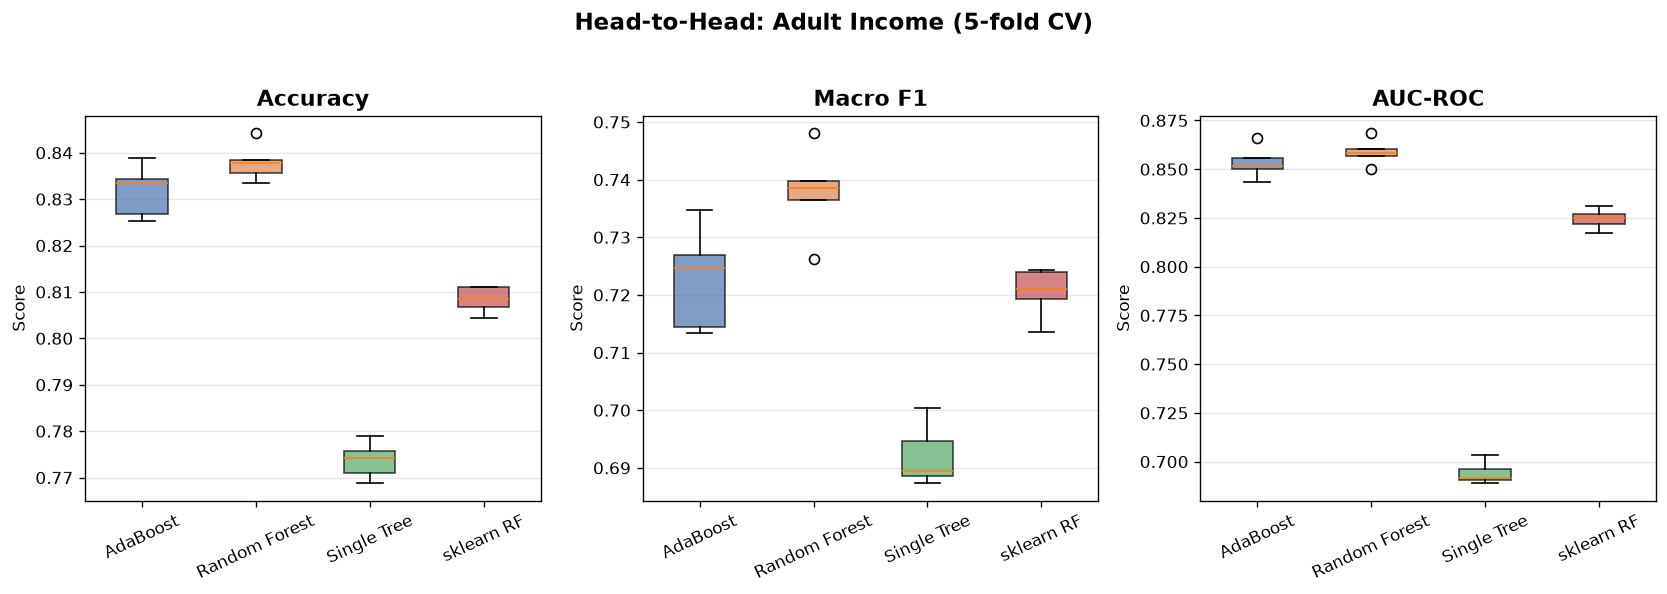

Box plot saved to: ../figures/head_to_head_adult_income.png


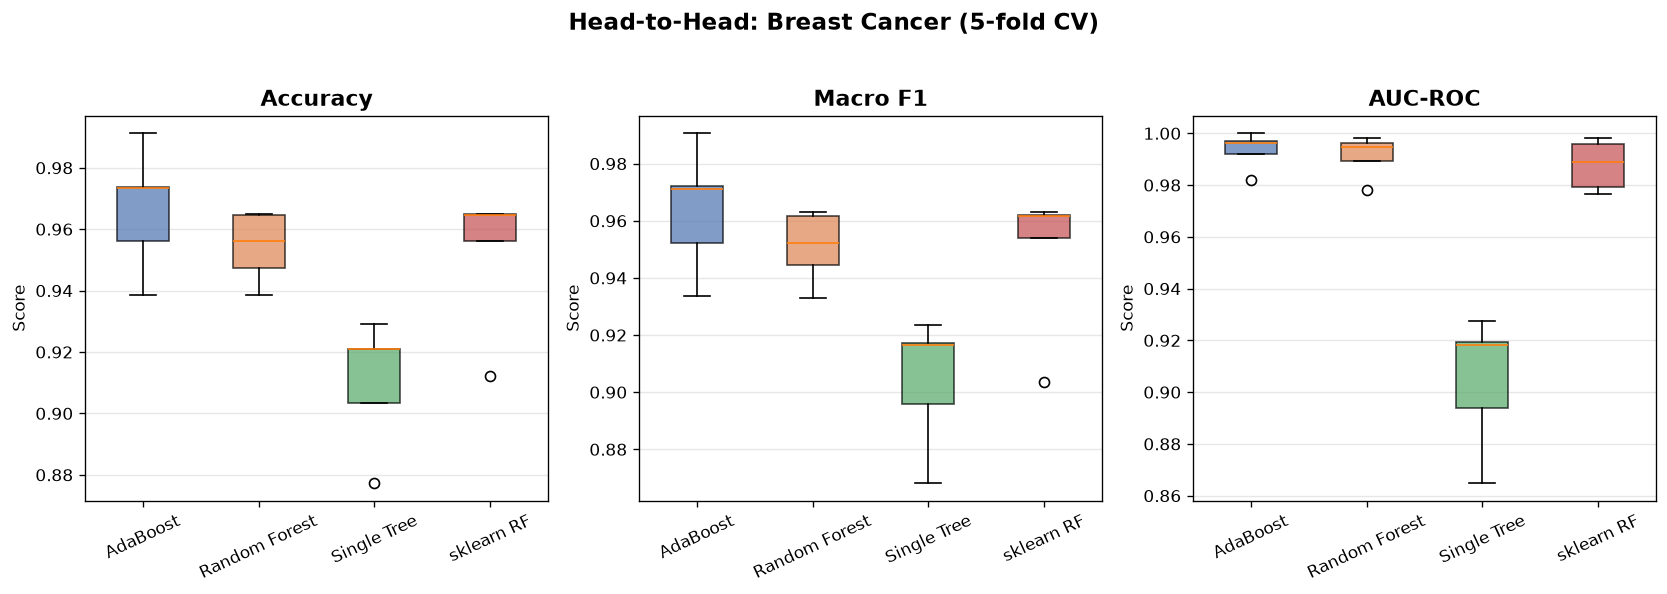

Box plot saved to: ../figures/head_to_head_breast_cancer.png


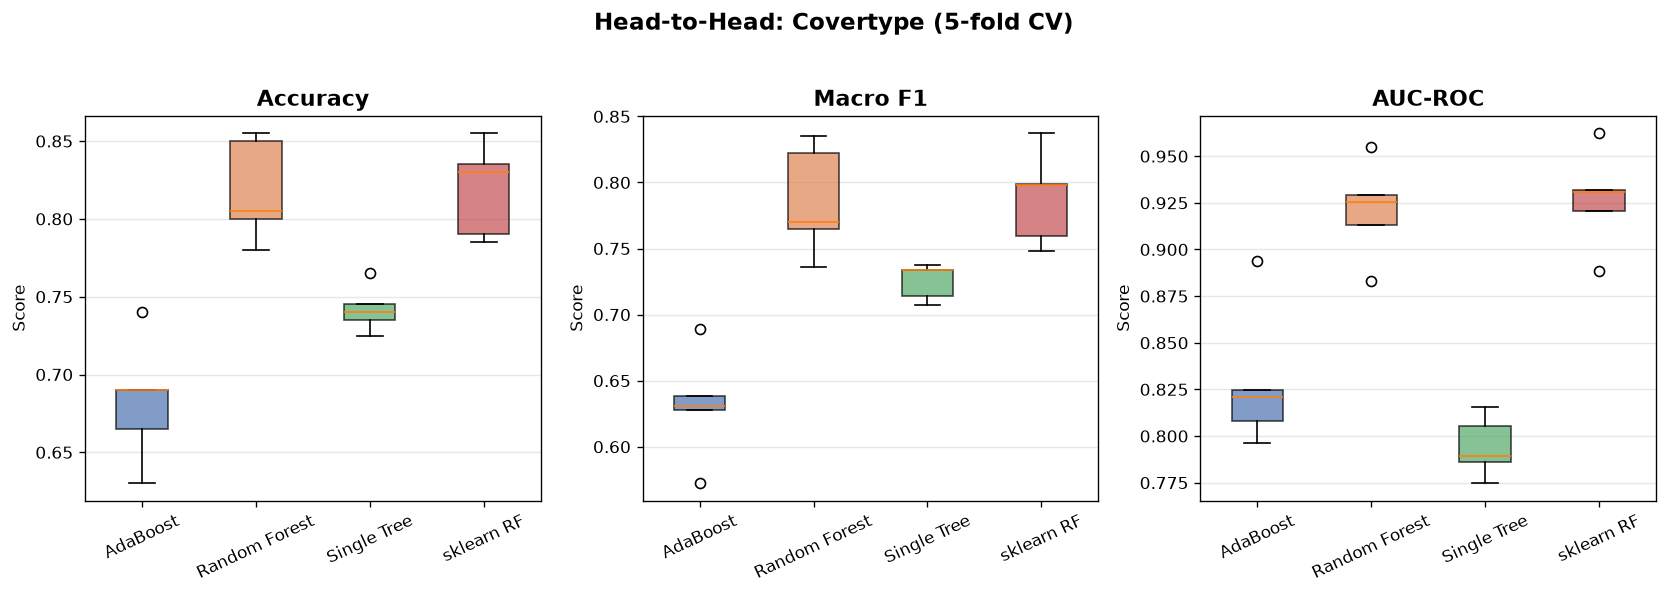

Box plot saved to: ../figures/head_to_head_covertype.png


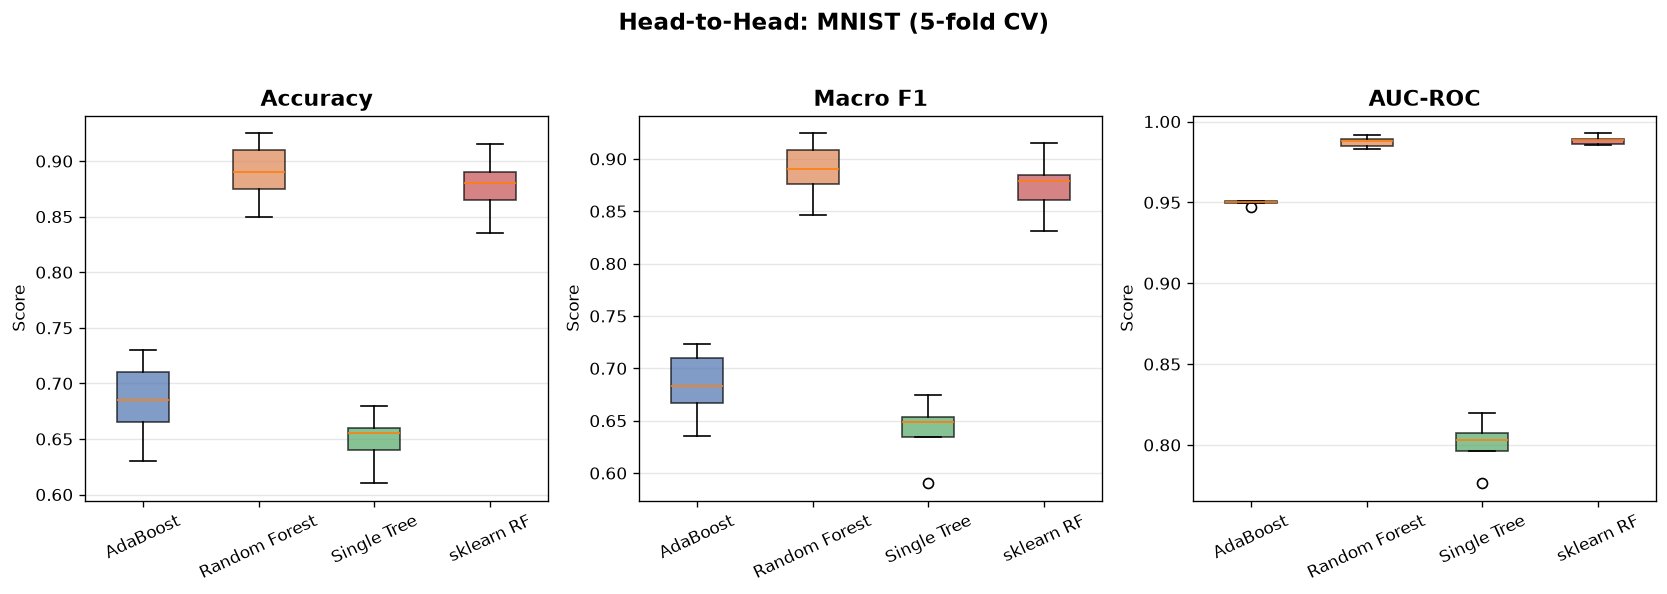

Box plot saved to: ../figures/head_to_head_mnist.png


In [14]:
os.makedirs("../figures", exist_ok=True)

metrics = ["acc", "f1", "auc"]
titles = ["Accuracy", "Macro F1", "AUC-ROC"]

colors = [
    "#4c72b0",
    "#dd8452",
    "#55a868",
    "#c44e52"
]


for dataset_name, cv_results in all_cv_results.items():

    names = list(cv_results.keys())

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(14, 5)
    )

    for ax, metric, title in zip(
        axes,
        metrics,
        titles
    ):

        data = [
            cv_results[name][metric]
            for name in names
        ]

        bp = ax.boxplot(
            data,
            tick_labels=names,
            patch_artist=True
        )

        for patch, color in zip(
            bp["boxes"],
            colors
        ):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_title(
            title,
            fontsize=13,
            fontweight="bold"
        )

        ax.set_ylabel(
            "Score"
        )

        ax.grid(
            axis="y",
            alpha=0.3
        )

        ax.tick_params(
            axis="x",
            rotation=25
        )


    fig.suptitle(
        f"Head-to-Head: {dataset_name} (5-fold CV)",
        fontsize=14,
        fontweight="bold"
    )

    fig.tight_layout(
        rect=[0, 0, 1, 0.95]
    )


    safe_filename = (
        dataset_name
        .lower()
        .replace(" ", "_")
    )

    save_path = (
        f"../figures/"
        f"head_to_head_{safe_filename}.png"
    )

    fig.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Box plot saved to: {save_path}"
    )

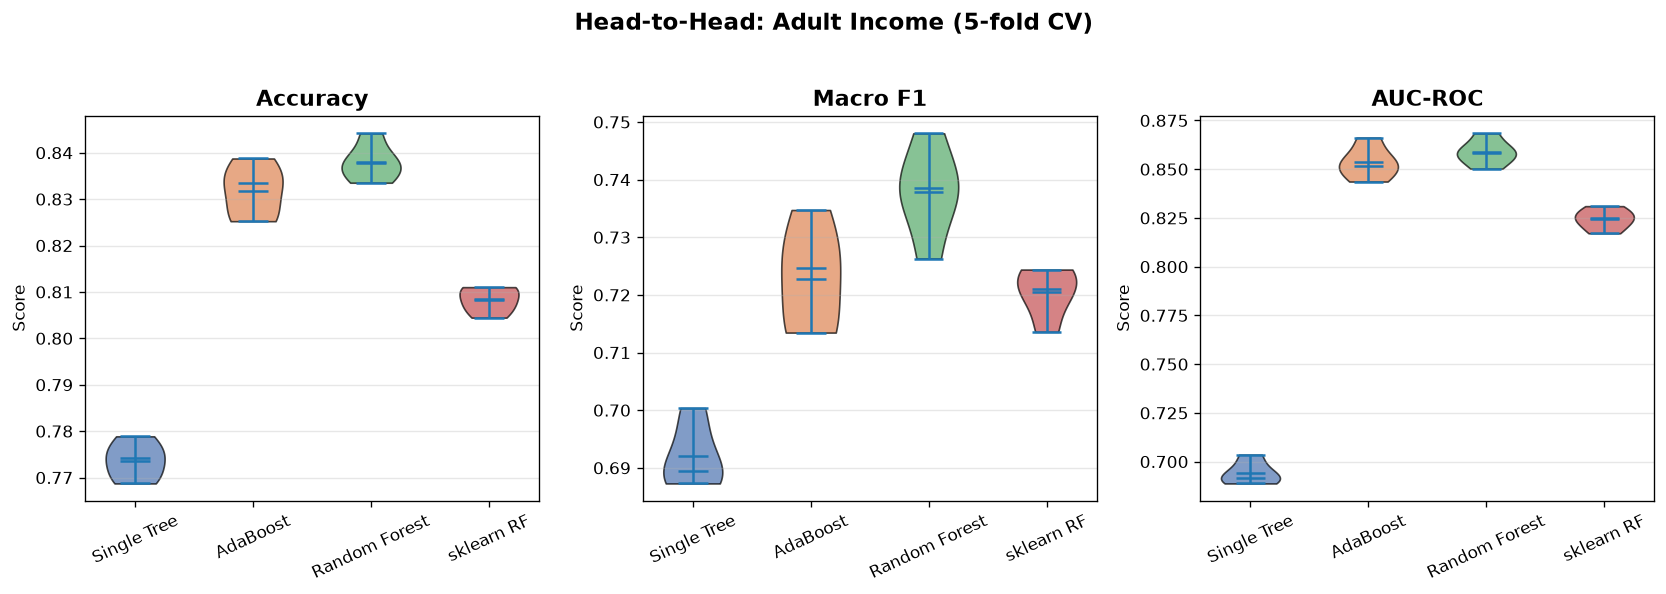

Violin plot saved to: ../figures/head_to_head_violin_adult_income.png


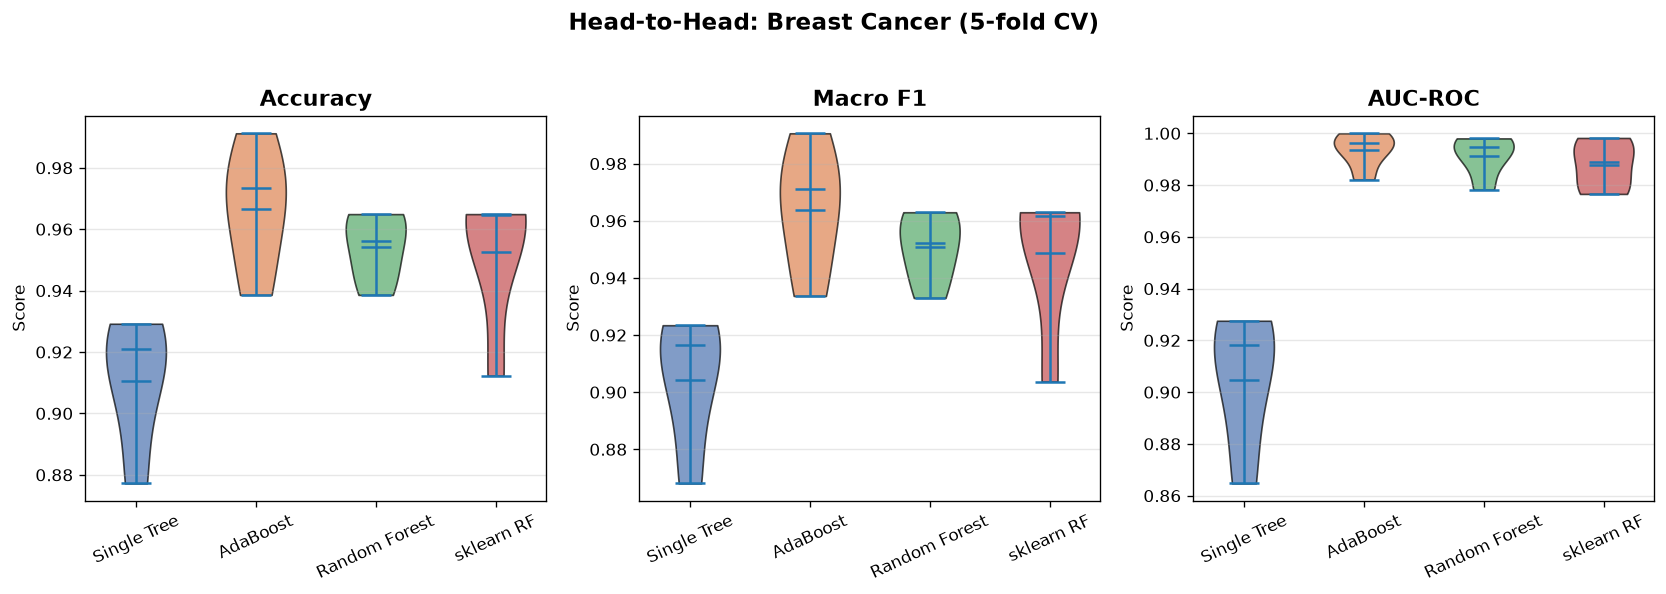

Violin plot saved to: ../figures/head_to_head_violin_breast_cancer.png


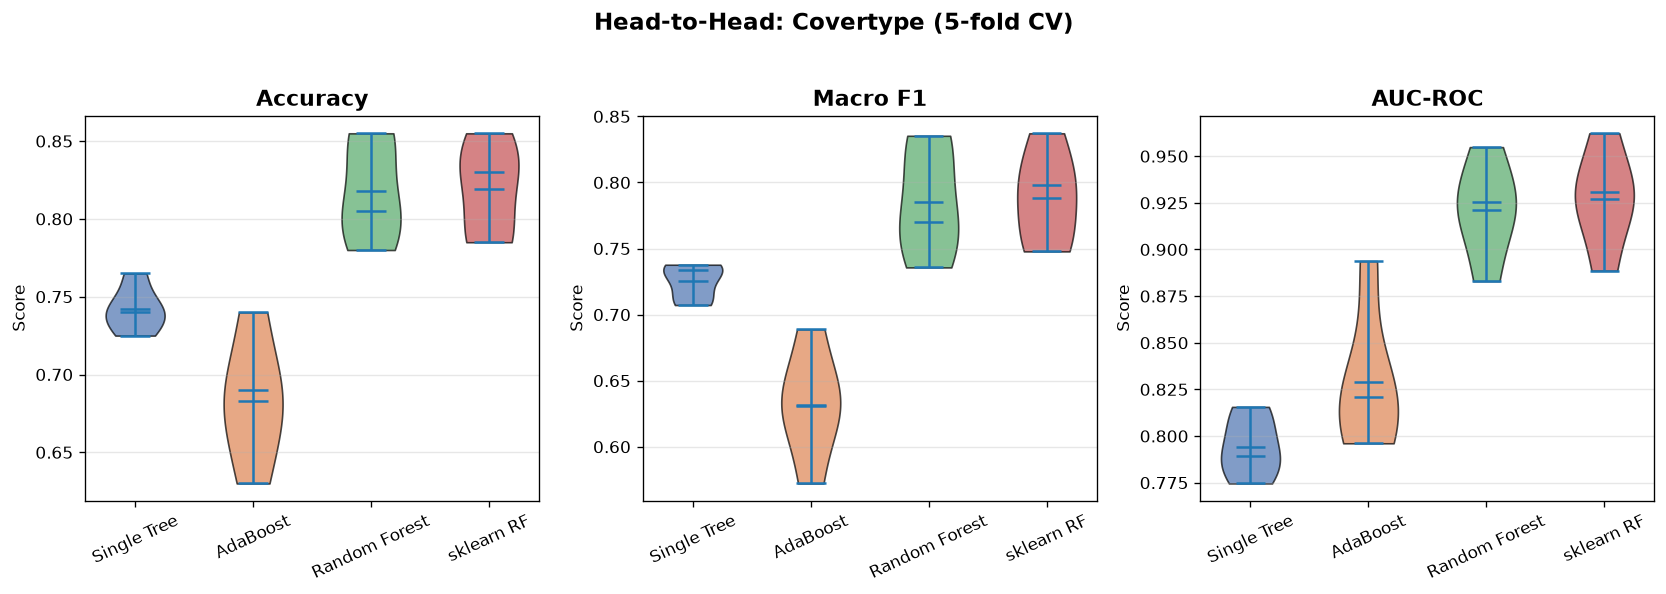

Violin plot saved to: ../figures/head_to_head_violin_covertype.png


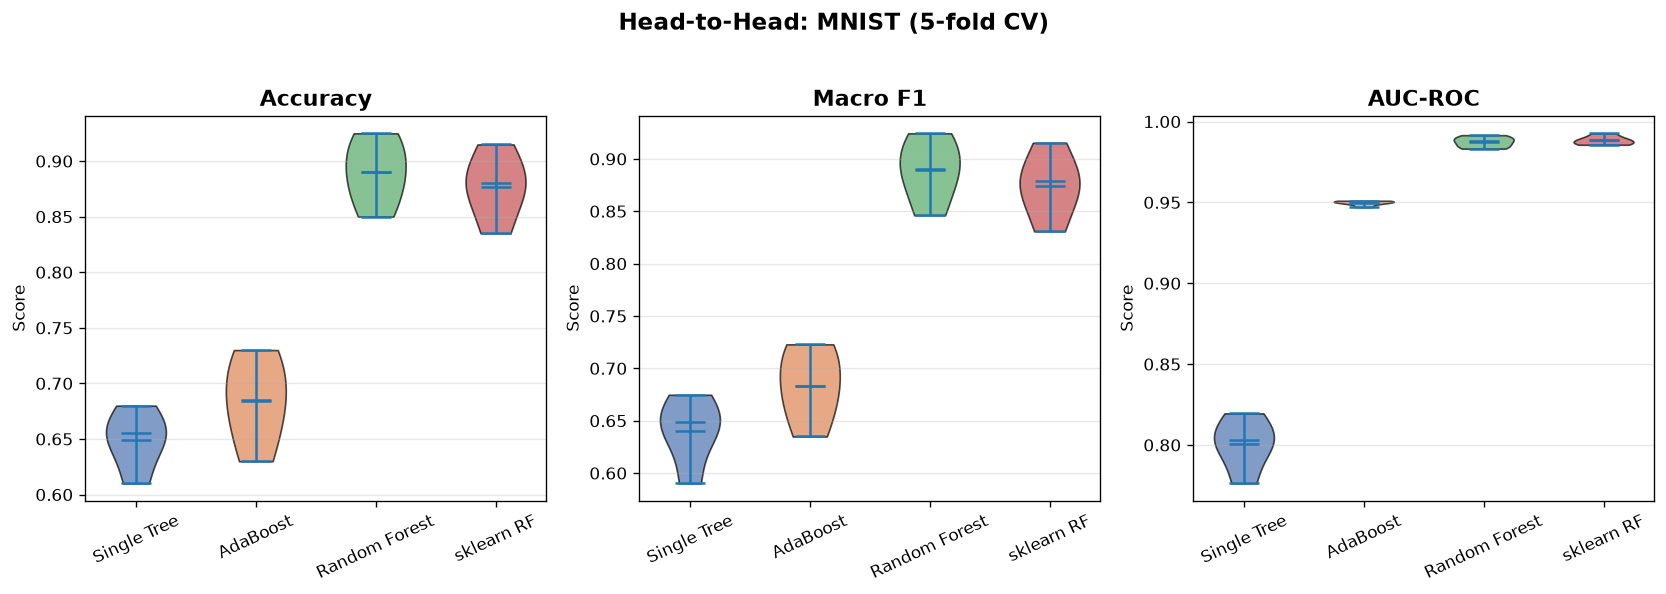

Violin plot saved to: ../figures/head_to_head_violin_mnist.png


In [15]:
metrics = [
    ("accuracy", "Accuracy"),
    ("macro_f1", "Macro F1"),
    ("auc_roc", "AUC-ROC"),
]

colors = [
    "#4c72b0",
    "#dd8452",
    "#55a868",
    "#c44e52"
]


# Bütün datasetlər üçün loop
for dataset_name in fold_results_df["dataset"].unique():

    dataset_df = fold_results_df[
        fold_results_df["dataset"] == dataset_name
    ]

    names = (
        dataset_df["model"]
        .unique()
        .tolist()
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(14, 5)
    )


    for ax, (metric, title) in zip(
        axes,
        metrics
    ):

        data = [
            dataset_df[
                dataset_df["model"] == model
            ][metric]
            .astype(float)
            .values
            for model in names
        ]


        vp = ax.violinplot(
            data,
            showmeans=True,
            showmedians=True,
            showextrema=True
        )


        for body, color in zip(
            vp["bodies"],
            colors
        ):
            body.set_facecolor(color)
            body.set_edgecolor("black")
            body.set_alpha(0.7)


        ax.set_xticks(
            range(1, len(names)+1)
        )

        ax.set_xticklabels(
            names,
            rotation=25
        )


        ax.set_title(
            title,
            fontsize=13,
            fontweight="bold"
        )

        ax.set_ylabel(
            "Score"
        )

        ax.grid(
            axis="y",
            alpha=0.3
        )


    fig.suptitle(
        f"Head-to-Head: {dataset_name} (5-fold CV)",
        fontsize=14,
        fontweight="bold"
    )


    fig.tight_layout(
        rect=[0, 0, 1, 0.95]
    )


    safe_filename = (
        dataset_name
        .lower()
        .replace(" ", "_")
    )

    save_path = (
        f"../figures/"
        f"head_to_head_violin_{safe_filename}.png"
    )


    fig.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Violin plot saved to: {save_path}"
    )